In [ ]:
from google.colab import files
files.upload()


Saving insurance.csv to insurance.csv


{'insurance.csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,32.4,1,no,southwe

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
X_lr = df_encoded.drop("charges", axis=1)
y_lr = df_encoded["charges"]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_lr)
X_test_lr = scaler.transform(X_test_lr)


In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train_lr, y_train_lr)

y_pred_lr = lin_model.predict(X_test_lr)


In [ ]:
mse = mean_squared_error(y_test_lr, y_pred_lr)
rmse = np.sqrt(mse)

r2 = r2_score(y_test_lr, y_pred_lr)

print("Linear Regression Performance")
print("RMSE:", rmse)
print("R2 Score:", r2)


Linear Regression Performance
RMSE: 5796.284659276274
R2 Score: 0.7835929767120722


In [ ]:
ridge_params = {'alpha': [0.1, 1, 10, 50]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5)
ridge_grid.fit(X_train_lr, y_train_lr)

print("Best Alpha:", ridge_grid.best_params_)


Best Alpha: {'alpha': 10}


In [ ]:
mean_charge = df_encoded["charges"].mean()
df_encoded["HighRisk"] = (df_encoded["charges"] > mean_charge).astype(int)


In [ ]:
X_log = df_encoded.drop(["charges", "HighRisk"], axis=1)
y_log = df_encoded["HighRisk"]

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_log = scaler.fit_transform(X_train_log)
X_test_log = scaler.transform(X_test_log)


In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_log, y_train_log)

y_pred_log = log_model.predict(X_test_log)


In [ ]:
print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test_log, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test_log, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_log, y_pred_log))


Logistic Regression Performance
Accuracy: 0.9104477611940298

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94       189
           1       1.00      0.70      0.82        79

    accuracy                           0.91       268
   macro avg       0.94      0.85      0.88       268
weighted avg       0.92      0.91      0.91       268


Confusion Matrix:
 [[189   0]
 [ 24  55]]


In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5)
grid.fit(X_train_log, y_train_log)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


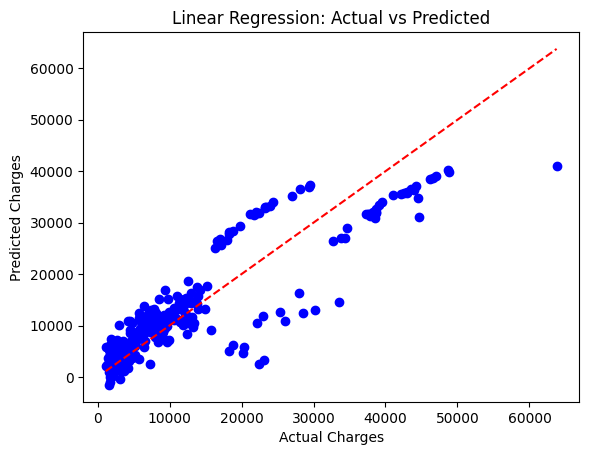

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test_lr, y_pred_lr, color='blue')
plt.plot([y_test_lr.min(), y_test_lr.max()],
         [y_test_lr.min(), y_test_lr.max()], 'r--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


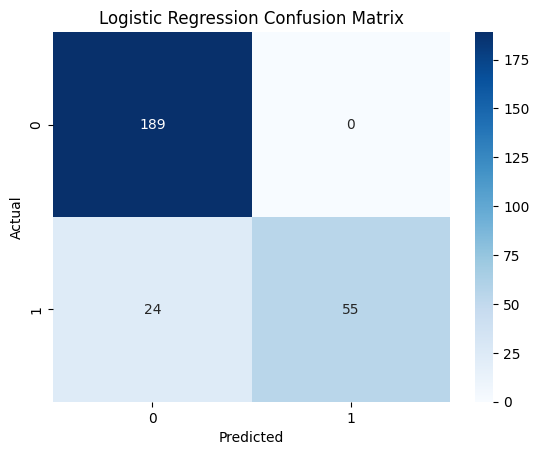

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_log, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()
